IA & Data science (LU3IN0226) -- 2025-2026
--------
*&copy; Equipe pédagogique: Christophe Marsala, Olivier Schwander, Jean-Noël Vittaut, Maxellende Julienne.*


# Projet final

<font size="+1" color="RED">**[Q]**</font> **Indiquer dans la boîte ci-dessous vos noms et prénoms :**

Alexandre Parant - Marc-Antoine Xia

Ce projet peut être fait en binôme ou tout seul.

**Le nom de chaque membre du binôme doit être indiqué dans la boîte ci-dessus**.


**Le compte-rendu est soumis sur la page Moodle.

Si vous êtes en binôme : **<u>un seul rendu doit être remis sur un seul des deux comptes du binôme</u>**.

Les groupes de plus de 2 personnes ne sont pas autorisés.

**La dernière séance de TD-TME11 de votre groupe sera réservée pour travailler sur ce mini-projet.**

<font color="RED" size="+1"><b>[Q]</b></font> **Renommer ce notebook**

**Nom à donner au fichier à poster** : *projet-Nom1_Nom2.ipynb* 
- *Nom1* et *Nom2* : noms des membres du binôme

Voir ci-dessous ce qui est à remettre.



# Projet - mai 2026

<b>Date de remise du compte-rendu : <font size="+1" color="RED">au plus tard le lundi 1er juin 2026, avant 10h</font></b>.
    
<b>Attention!</b> le site Moodle ferme à 20h pile (heure du site Moodle)! prévoyez de vous y connecter au moins 15mn avant la fermeture...
<b>Il n'y aura pas de prolongation possible.</b>

## Travail à faire

Vous devez compléter ce notebook en rajoutant vos expérimentations avec vos algorithmes d'apprentissage (supervisé et non-supervisé) sur les données Fashion MNIST fournies (voir plus loin).

Vous devez appliquer les algorithmes d'apprentissage vus en cours et réaliser une analyse sur les données afin de mettre en évidence des résultats intéressants.

Les données seront chargées par les commandes de chargement des données fournies dans ce notebook (ci-dessous).
Dans le notebook que vous rendrez, le chargement des fichiers de données doit considérer cette arborescence.


## Remarque: utilisation d'IA générative 

Toute utilisation d'une IA générative (ChatGPT, Mistral, Claude,...) pour réaliser certains traitements de ce projet doit **obligatoirement** être indiqué dans votre notebook. De plus, si vous utilisez une telle IA générative, vous devez pouvoir être capable d'expliquer ce qu'elle vous a fourni et que vous avez utilisé.

## Compte-rendu demandé
Ce qui doit être remis avant la date limite : un unique fichier archive compressé (`.tgz`, ou `.zip` uniquement) de nom :
`projet-Nom1_Nom2.tgz` ou `projet-Nom1_Nom2.zip` contenant:
- ce **notebook** complété (et avec vos noms !). Il doit pouvoir être exécuté sans autre apport (pensez à vous en assurer avant de le rendre). 
- votre **librairie iads** complète, c'est à dire votre répertoire `iads/` contenant tous les fichiers python complets.
- un **poster** sous la forme d'un fichier PDF dont le nom est de la forme: *tme11-Nom1_Nom2.pdf* qui correspond à un poster décrivant l'ensemble des expérimentations menées et les résultats obtenus.


**Très important** : les fichiers dans l'archive doivent être placés de façon à respecter la structure de fichiers suivante :

          --projet-Nom1_Nom2/
              --iads/
                  -- Classifiers.py
                  -- etc.
              -- Projet/
                  --  projet-Nom1_Nom2.ipynb


<b>Remarque</b>: 
- **Les <u>fichiers de données ne doivent pas être inclus dans votre archive</u>** ! 
- Pensez à vérifier que votre archive contient bien tous les fichiers demandés et **seulement** les fichiers demandés.
- **Tous les fichiers demandés doivent être soumis avant la date limite**, en une seule archive comme indiqué ci-dessus.

## Soutenance des projets
**Les soutenances auront lieu le <font size="+1" color="RED">mardi 2 juin 2026</font>, à partir de 14h**. 

Un ordre de passage ainsi que la salle de TME où elles auront lieu seront affichées sur le Moodle la veille (la remise d'un compte-rendu à la date d'échéance indiquée (avant le lundi 1er juin 2026, 10h) est **obligatoire** pour passer une soutenance).

La <b>soutenance est obligatoire</b> : <u>tout projet pour lequel la soutenance n'est pas passée sera noté $0$</u>.

Modalités de la soutenance:
- durée de la soutenance : 10 mn pour un binôme, 7 mn pour un monôme ;
- elle a lieu devant un ordinateur avec le notebook et le poster comme support ;
    - elle commence par une rapide présentation des expérimentations réalisées et résultats obtenus (max. 4 à 5mns)
    - puis elle se poursuit par des questions posées individuellement aux membres du binômes sur les expériences ou le code python réalisé.
- la note de soutenance est individuelle pour chaque membre d'un binôme.



In [1]:
# - - - - - - - - - - - - - - - - - -
# imports utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtpl
%matplotlib inline  

import math
import time
import sys

# pour les dendrogrammes :)
import scipy

# --------------------------------
# Les instructions suivantes sont utiles pour recharger automatiquement 
# le code modifié dans les librairies externes
%load_ext autoreload
%autoreload 2
# --------------------------------


In [2]:
# Importation de votre librairie iads:
# La ligne suivante permet de préciser le chemin d'accès à la librairie iads
sys.path.append('../')   # iads doit être dans le répertoire père du répertoire courant !

# Importation de la librairie iads
import iads as iads

# importation de Classifiers
from iads import Classifiers as cl

# importation de utils
from iads import utils as ut

# importation de evaluation
from iads import evaluation as ev

# importation de Clustering 
from iads import Clustering as clust


## Données pour le projet : Fashion MNIST

Les données sont fournies dans l'archive `data.tgz`. 
Cette archive contient 2 fichiers CSV:
- le fichier `fashion-mnist_train.csv`: ce fichier doit servir à l'entraînement de vos modèles, et leur évaluation en validation croisée,
- le fichier `fashion-mnist_test.csv`: ce fichier ne doit être utilisé que pour évaluer un modèle et il ne doit pas servir pour faire mettre au point le modèle.


Une documentation sur ces données peut être consultée sur la <a href="https://fr.wikipedia.org/wiki/Fashion_MNIST" target="NEW">page wikipedia Fashion MNIST</a>.


#### Chargement des données

In [3]:
data_train = pd.read_csv("../data/fashion-mnist_train.csv")
data_train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
data_test = pd.read_csv("../data/fashion-mnist_test.csv")
data_test

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,32,23,14,20,0,0,1,0,0,0
9996,6,0,0,0,0,0,0,0,0,0,...,0,0,0,2,52,23,28,0,0,0
9997,8,0,0,0,0,0,0,0,0,0,...,175,172,172,182,199,222,42,0,1,0
9998,8,0,1,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [5]:
data_train.shape

(60000, 785)

In [6]:
data_test.shape

(10000, 785)

## Tâches à réaliser

### Apprentissage supervisé

*Tâches*: évaluation d'algorithmes et de représentations des données.
- classification binaire
- classification multi-classe

*Etudes suggérées*:
- différents classifiers:
    - perceptron et variantes
    - k-plus proches voisins 
    - arbres de décision
    - ensembles de classifieurs
- analyse des résultats: comparaison des approches et de leurs hyper-paramètres
    - accuracy, temps d'exécutions
    - score fold par fold
    - matrice de confusion
    - ...


### Apprentissage non-supervisé

*Tâche*: présence éventuelle de groupes de données: groupes intra-classes, et/ou groupes interclasses.

*Etudes possibles*:
- étudier l'application d'un clustering hiérarchique et son résultat;
- étudier les résultats de l'application de l'algorithme des k-moyennes, pour différentes valeurs de k: roposer des évaluations des clusters trouvés afin de mettre en évidence les plus intéressants:
    - en utilisant les indices d'évaluation présentés en cours;
    - en comparant par diverses méthodes les clusters trouvés avec les vrais labels des classes (targets y).
- proposer une visualisation des résultats obtenus
- analyse des exemples mal-classés: est-ce qu'ils forment un (ou des) sous-groupes?
- ...


   


## Poster à rendre dans le compte-rendu (format PDF)

Votre poster doit décrire de façon synthétique **l'ensemble des expérimentations** menées sur les données, les résultats obtenus en apprentissage supervisé et en apprentissage non-supervisé ainsi que les conclusions/bilans que vous tirez de ces expérimentations (ie. ce que vous avez appris sur ces données).

**Important*: vous devez indiquer vos noms/prénoms sur le poster.


# Votre travail commence à partir d'ici 

## Chargement des données, normalisation

In [7]:
# Train
data_train_X = data_train.drop(['label'], axis=1)
data_train_Y = data_train["label"]

# Test
data_test_X = data_test.drop(['label'], axis=1)
data_test_Y = data_test["label"]

X = (data_train_X.to_numpy() - 127) / 128
Y = data_train_Y.to_numpy()

Xt = (data_test_X.to_numpy() - 127) / 128
Yt = data_test_Y.to_numpy()

dim = X.shape[1]
Nc = 10

idx_to_type = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
    ]

## Verification des données

(60000, 784)
(60000,)


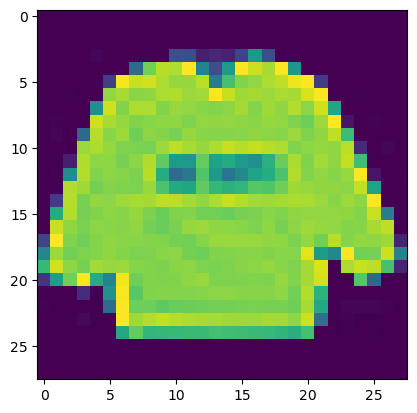

In [8]:
print(X.shape)
print(Y.shape)
plt.figure()
plt.imshow(X[0].reshape((28, 28)))

In [9]:
for i in range(Nc):
    print(f"Nombre d'exemples de {i}: {X[Y == i].shape}")

Nombre d'exemples de 0: (6000, 784)
Nombre d'exemples de 1: (6000, 784)
Nombre d'exemples de 2: (6000, 784)
Nombre d'exemples de 3: (6000, 784)
Nombre d'exemples de 4: (6000, 784)
Nombre d'exemples de 5: (6000, 784)
Nombre d'exemples de 6: (6000, 784)
Nombre d'exemples de 7: (6000, 784)
Nombre d'exemples de 8: (6000, 784)
Nombre d'exemples de 9: (6000, 784)


In [10]:
# Création de sous jeux de données (de teste et train)
Xm, Ym = ut.getSampleDataset(X, Y, 0, 2, 6000)
Xtm, Ytm = ut.getSampleDataset(Xt, Yt, 0, 2, 600)

Xm38, Ym38 = ut.getSampleDataset(X, Y, 3, 8, 6000)
Xtm38, Ytm38 = ut.getSampleDataset(Xt, Yt, 3, 8, 600)

Xma, Yma = ut.getSampleDataset(X, Y, None, None, 6000)
Xtma, Ytma = ut.getSampleDataset(Xt, Yt, None, None, 600)

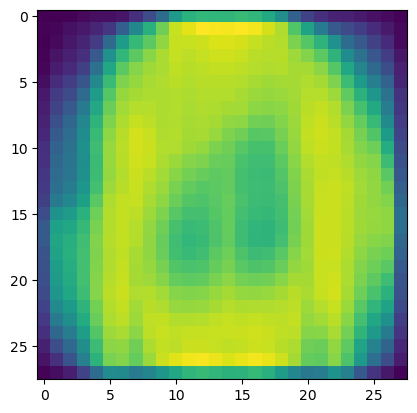

In [11]:
plt.imshow(np.std(Xma, axis=0).reshape((28, 28)))

Zones claires -> zone de grande écart-type -> zones de différentiation

## Classifieur binaire KNN

[np.float64(0.9566666666666667), np.float64(0.955), np.float64(0.9516666666666667), np.float64(0.9516666666666667), np.float64(0.9483333333333334), np.float64(0.95), np.float64(0.9533333333333334), np.float64(0.9533333333333334)]


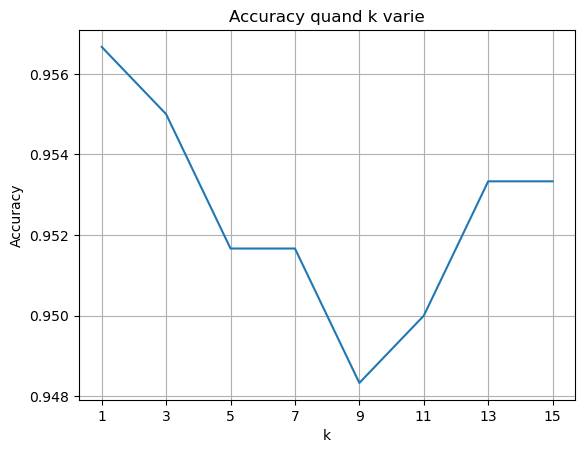

In [13]:
# Variables
L_accuracies = []
k_max = 15

# Éxecute le classifier pour différent k
for k in range(1, k_max+1, 2):
    classifieur_KNN = cl.ClassifierKNN(dim, k)
    classifieur_KNN.train(Xm, Ym)
    accuracy = classifieur_KNN.accuracy(Xtm,Ytm)
    L_accuracies.append(accuracy)
    
print(L_accuracies)

# Informations d'affichage :
plt.title("Accuracy quand k varie")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.xticks([v for v in range(1,k_max+1,2)])
plt.plot(range(1,k_max+1, 2), L_accuracies)

plt.show()

le classifier KNN est à une "précision" plutôt bonne pour différencier la classe 0 à 2. 

## Validation croisée

In [38]:
classifieur_KNN = cl.ClassifierKNN(dim, 3)
ev.validation_croisee(classifieur_KNN, (Xm38, Ym38), 5)

([np.float64(0.9925),
  np.float64(0.9841666666666666),
  np.float64(0.9925),
  np.float64(0.9833333333333333),
  np.float64(0.9866666666666667)],
 np.float64(0.9878333333333333),
 np.float64(0.003965125751123479))

Les résultats sont satisfaisant  pour la classification binaire en validation croisée. (3 = bag, 8 = dress)
Et l'écart type est aussi faible montre une bonne consistence

## Classifieur Multiclasse KNN

[np.float64(0.8283333333333334), np.float64(0.8083333333333333), np.float64(0.8183333333333334), np.float64(0.8233333333333334), np.float64(0.81), np.float64(0.8016666666666666), np.float64(0.81), np.float64(0.8083333333333333), np.float64(0.8066666666666666), np.float64(0.7983333333333333)]


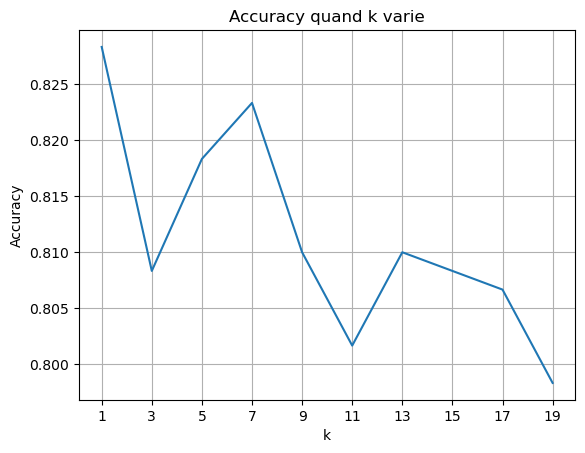

In [14]:
L_accuracies = []
k_max = 20

for k in range(1, k_max+1, 2):
    classifieur_KNN = cl.ClassifierKNN_MC(dim, k, Nc)
    classifieur_KNN.train(Xma, Yma)
    accuracy = classifieur_KNN.accuracy(Xtma,Ytma)
    L_accuracies.append(accuracy)
    
print(L_accuracies)

# Informations d'affichage :
plt.title("Accuracy quand k varie")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.xticks([v for v in range(1,k_max+1,2)])
plt.plot(range(1,k_max+1, 2), L_accuracies)

plt.show()

Le multiclasse semble poser un plus gros problème vu qu'elle est dans les alentour de 0.815 par rapport à la non MC qui est de 0.9.
Mais cela est sûrement du au choix que nous avons fait précédement: Choisir les classe 0 et 2 alors que sur le MC, on fait pour toutes les classes
=> Les classes 0 et 2 sont plus simple à comparer entre eux que d'autres de la base de données et donc l'accuracy est moins élevé quand on compare à l'ensemble des autres exemples

## Classifieur Perceptron stabilisé

In [12]:
eps = 1e-3    # learning rate
perceptronStab = cl.ClassifierPerceptronStable(dim, learning_rate=eps, init=True,verbose=False)

In [27]:
print("Perceptron entre les classes 0 et 2")
les_differences = perceptronStab.train(Xm,Ym,nb_max=1000,verbose=False)

print(f"Accuracy avec data de Train:\t{perceptronStab.accuracy(Xm,Ym):1.4f}")
print(f"Accuracy Test:\t{perceptronStab.accuracy(Xtm,Ytm):1.4f}")

Perceptron entre les classes 0 et 2
Accuracy avec data de Train:	0.9990
Accuracy Test:	0.9133


In [24]:
print("Perceptron entre les classes 3 et 8")
les_differences = perceptronStab.train(Xm38,Ym38,nb_max=1000,verbose=False)
print(f"Accuracy Test:\t{perceptronStab.accuracy(Xtm38,Ytm38):1.4f}")

Perceptron entre les classes 3 et 8
Accuracy Test:	0.9683


## Classifieur Multi Perceptron stabilisé

In [12]:
eps = 1e-3

clb = cl.ClassifierPerceptronStable(dim, learning_rate=eps, init=True)
perceptron_mc = cl.ClassifierMultiOAA(dim, clb)
perceptron_mc.train(Xma,Yma)
print(f"Accuracy: {perceptron_mc.accuracy(Xtma,Ytma)}")

Accuracy: 0.7866666666666666


Un scénario similaire se produit, nous avons probablement affaire à la malédiction des dimensions, il y a probablement trop peu d'informations qui peuvent être a travers les 784 pixels

-> Toujours moins bon quand on fait toutes les classes comparé à la 0 et 2


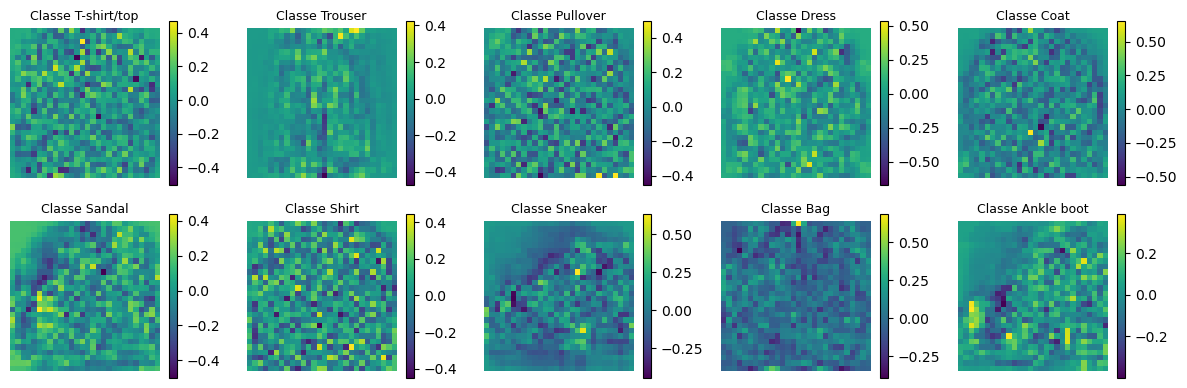

In [95]:
fig, axes = plt.subplots(2, 5, figsize=(12, 4))
axes = axes.flatten()

for i in range(10):
    ax = axes[i]
    im = ax.imshow(perceptron_mc._ClassifierMultiOAA__lCl[i]._ClassifierPerceptron__w[:784].reshape((28, 28)))
    fig.colorbar(im, ax=ax, orientation='vertical')
    ax.set_title(f"Classe {idx_to_type[i]}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig("w.png")
plt.show()

Couleur fortes = zones importantes, ou observe ainsi une silouhette dessinée avec les poids du perceptron

## Réduction de la dimensionalité

/tmp/ipykernel_401813/947844918.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_proj[mask, 0], X_proj[mask, 1], c=colors[c], label=f"Classe {c}", marker="o", s=8, alpha=0.2)


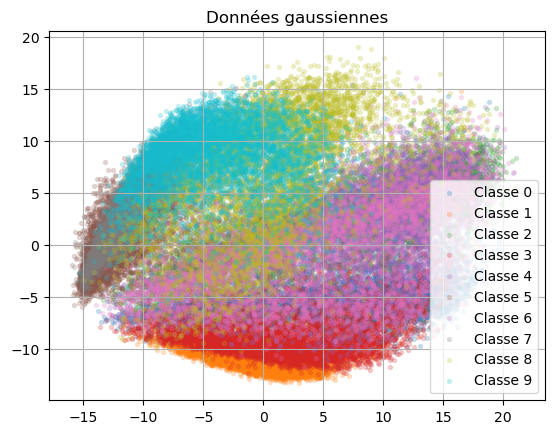

In [13]:
# Visualiser les données en 2D
import matplotlib.colors as mcolors

# 1) calcul des vecteurs propres
Xc = X - np.mean(X, axis=0)
Cov = np.cov(Xc.T)
ValP, VectP = np.linalg.eig(Cov) 

# 3) tri et sélection des 2 vecteurs associés aux 2 plus grandes valeurs propres 
idx = np.argsort(ValP)[::-1]
vproj = VectP[:, idx[:2]] 
X_proj = np.dot(Xc, vproj)

colors = plt.cm.tab10.colors

# 4) affichage (plot) avec un code couleur pour les classes
plt.figure()
for c in range(Nc):
    mask = (Y == c)
    plt.scatter(X_proj[mask, 0], X_proj[mask, 1], c=colors[c], label=f"Classe {c}", marker="o", s=8, alpha=0.2)

plt.title('Données gaussiennes')
plt.legend()
plt.grid(True)
plt.savefig("acp.png")

On vois que 7 et 9 donc sneaker et ankle boot sont proches et que shirt en rose et t shirt en bleu est très variable et s'étend sur tout le croissant inférieur

In [14]:
ndim = dim // 10

Xr = np.dot(Xma, VectP[:,:ndim])
XTr = np.dot(Xtma, VectP[:,:ndim])
Xr = (Xr - Xr.mean(axis=0)) / (Xr.std(axis=0))
XTr = (XTr - XTr.mean(axis=0)) / (XTr.std(axis=0))

In [48]:
eps = 1e-3
modele_reduit = cl.ClassifierPerceptronStable(input_dimension=ndim, learning_rate=eps, init=True, verbose=False)
clmulti_reduit = cl.ClassifierMultiOAA(ndim, modele_reduit)

tic = time.time()  # On lance le chrono
clmulti_reduit.train(Xr, Yma)
toc = time.time()  # On arrête le chrono

perf_A = clmulti_reduit.accuracy(Xr, Yma)
perf_T = clmulti_reduit.accuracy(XTr, Ytma)

print(f"\nTaux de bonne classification : Train: {perf_A:.4}, Test: {perf_T:.4}, en {toc-tic:0.4} secondes")


Taux de bonne classification : Train: 0.844, Test: 0.805, en 13.48 secondes


Les choses semblent s'améliorer! Ou en tout cas ni dégradées et en revanche accélérées. Essayons de trouver un bon learning rate

[np.float64(0.7966666666666666), np.float64(0.8083333333333333), np.float64(0.8116666666666666), np.float64(0.8216666666666667), np.float64(0.7833333333333333)]


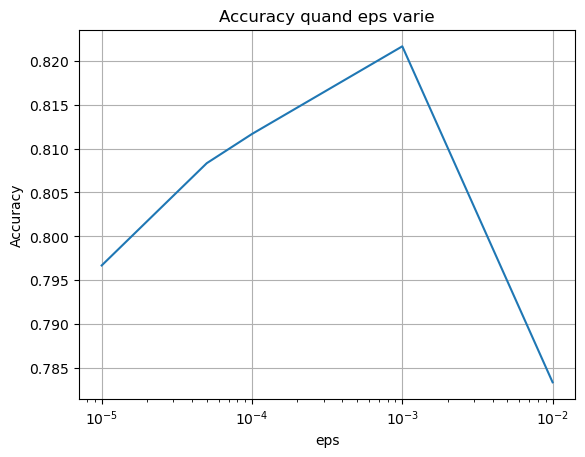

In [49]:
L_eps = [0.00001, 0.00005, 0.0001, 0.001, 0.01]
L_accuracies = []

for eps in L_eps:
    modele_reduit = cl.ClassifierPerceptronStable(input_dimension=ndim, learning_rate=eps, init=True, verbose=False)
    clmulti_reduit = cl.ClassifierMultiOAA(ndim, modele_reduit)
    clmulti_reduit.train(Xr, Yma)
    accuracy = clmulti_reduit.accuracy(XTr, Ytma)
    L_accuracies.append(accuracy)
    
print(L_accuracies)

# Informations d'affichage :
plt.title("Accuracy quand eps varie")
plt.xlabel("eps")
plt.ylabel("Accuracy")
plt.grid(True)
plt.semilogx(L_eps, L_accuracies)

plt.show()

10e-3 semble être une bonne valeur

In [50]:
modele_reduit = cl.ClassifierPerceptronStable(input_dimension=ndim, learning_rate=0.001, init=True, verbose=False)
clmulti_reduit = cl.ClassifierMultiOAA(ndim, modele_reduit)
ev.validation_croisee(clmulti_reduit, (Xr, Yma), 5)

([np.float64(0.825),
  np.float64(0.8341666666666666),
  np.float64(0.8233333333333334),
  np.float64(0.81),
  np.float64(0.8116666666666666)],
 np.float64(0.8208333333333334),
 np.float64(0.00897527467855748))

## Arbre numérique

In [ ]:
import graphviz as gv

seuilEntropie = 0.4
arbre = cl.ClassifierArbreNumerique(dim, seuilEntropie, [])

arbre.train(Xr, Yma, False)

graphe_arbre = gv.Digraph(format='png')
arbre.affiche(graphe_arbre)

print("Cet arbre possède ", arbre.number_leaves()," feuilles.")
#graphe_arbre # ------> MIS EN COMMENTAIRE POUR MIEUX VOIR DANS LE NOTEBOOK

Cet arbre possède  584  feuilles.


On obtient un arbre peut compréhensible du au nombre de label (28 x 28 label = au nombre de pixel)
// il faudrais d'abord regroupé les pixel en moyennent leur valeur puis refaire (possiblement plus compréhensible)
// Ajouter le  nom des pixel à la place des att_XXX -> ce fait en  remplacent la liste en haut qui est vide actuellement

In [77]:
# mesure du taux de bonne classifications
print(f"accuracy train: {arbre.accuracy(Xr,Yma)}")
print(f"accuracy teste: {arbre.accuracy(XTr,Ytma)}")
# arbre._ClassifierArbreNumerique__racine.affiche_debug()

accuracy train: 0.8876666666666667
accuracy teste: 0.6683333333333333


On est vraisemblablement en situation d'overfit / surapprentissage, avec un train proche de 1 mais un test de 70%

seuil d'entropie = 0.100 accuracy moyenne: 0.69)
seuil d'entropie = 0.201 accuracy moyenne: 0.6983333333333334)
seuil d'entropie = 0.302 accuracy moyenne: 0.7)
seuil d'entropie = 0.403 accuracy moyenne: 0.6666666666666666)
seuil d'entropie = 0.504 accuracy moyenne: 0.6533333333333333)


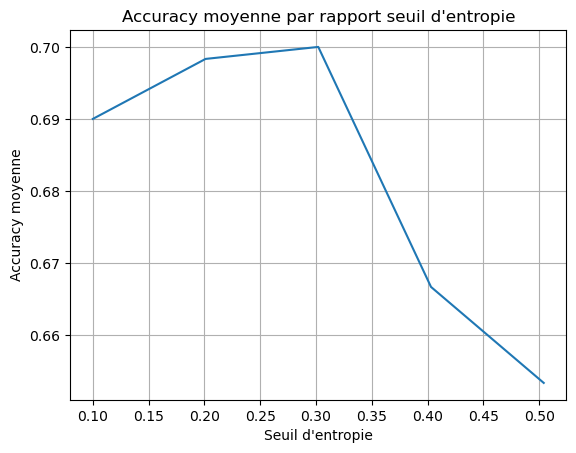

In [ ]:
veps = np.arange(0.1, 0.5+0.101, 0.101)
vacc = []
for eps in veps:
    arbre2 = cl.ClassifierArbreNumerique(ndim ,eps, [])
    arbre2.train(Xr, Yma)
    res_moy = arbre2.accuracy(XTr,Ytma)
    print(f"seuil d'entropie = {eps:.3f} accuracy moyenne: {res_moy})")
    vacc.append(res_moy)

# Affichage
plt.title("Accuracy moyenne par rapport seuil d'entropie")
plt.ylabel("Accuracy moyenne")
plt.xlabel("Seuil d'entropie")
plt.grid(True)
plt.plot(veps, vacc)

Ces résultats sont attendu d'un DT sur des données visuelles, car l'arbre de décision essaie de classifier selon des pixels individuels à chaque itération, contrairement au algorithmes vu plus tôt comme le perceptron ou KNN qui prennent à chaque décision tout les pixels en même en compte.

In [78]:
debut = time.time()
clps = cl.ClassifierPerceptronStable(input_dimension=ndim, learning_rate=0.001, init=True, verbose=False)
clpsm = cl.ClassifierMultiOAA(ndim, clps)
psm_perf, psm_moy, psm_std = ev.validation_croisee(clpsm, (Xr, Yma), 5, True)
fin = time.time()
tpsm = fin-debut
print(f"Temps pris pour le perceptron stabilisé avec biais: {fin-debut:.2}s")

Analyse perf : moyenne: 0.8227	ecart: 0.0065
Temps pris pour le perceptron stabilisé avec biais: 5.5e+01s


In [79]:
debut = time.time()
arbre2 = cl.ClassifierArbreNumerique(ndim ,0.5, [])
dt_perf, dt_moy, dt_std = ev.validation_croisee(arbre2, (Xr, Yma), 5, True)
fin = time.time()
tdt = fin-debut
print(f"Temps pris pour l'arbre de décision: {fin-debut:.2}s")

Analyse perf : moyenne: 0.6268	ecart: 0.0287
Temps pris pour l'arbre de décision: 7e+02s


In [80]:
debut = time.time()
cknnmc = cl.ClassifierKNN_MC(dim, 7, Nc)
knnmc_perf, knnmc_moy, knnmc_std = ev.validation_croisee(cknnmc, (Xr, Yma), 5, True)
fin = time.time()
tknn = fin-debut
print(f"Temps pris pour KNN: {fin-debut:.2}s")

Analyse perf : moyenne: 0.7977	ecart: 0.0045
Temps pris pour KNN: 5.5s


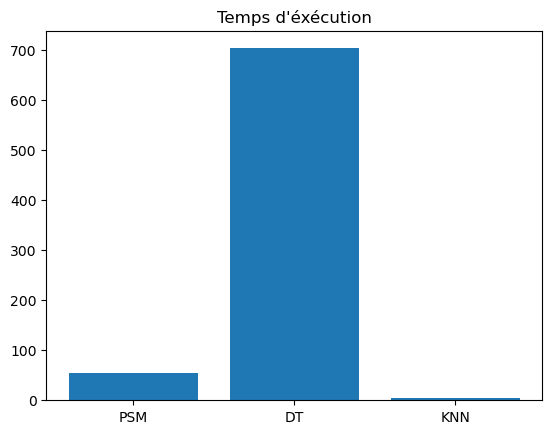

In [97]:
plt.bar(["PSM", "DT", "KNN"], [tpsm, tdt, tknn])
plt.title("Temps d'éxécution")
plt.savefig("t.png")

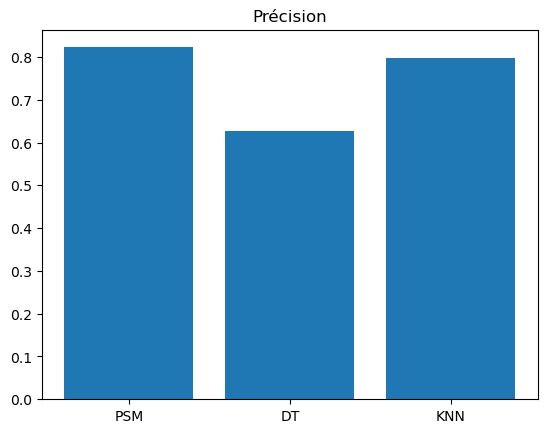

In [98]:
plt.bar(["PSM", "DT", "KNN"], [psm_moy, dt_moy, knnmc_moy])
plt.title("Précision")
plt.savefig("acc.png")

In [85]:
clps = cl.ClassifierPerceptronStable(input_dimension=ndim, learning_rate=0.001, init=True, verbose=False)
clpsm = cl.ClassifierMultiOAA(ndim, clps)
clpsm.train(Xr, Yma)
y_pred = np.array([clpsm.predict(x) for x in XTr])

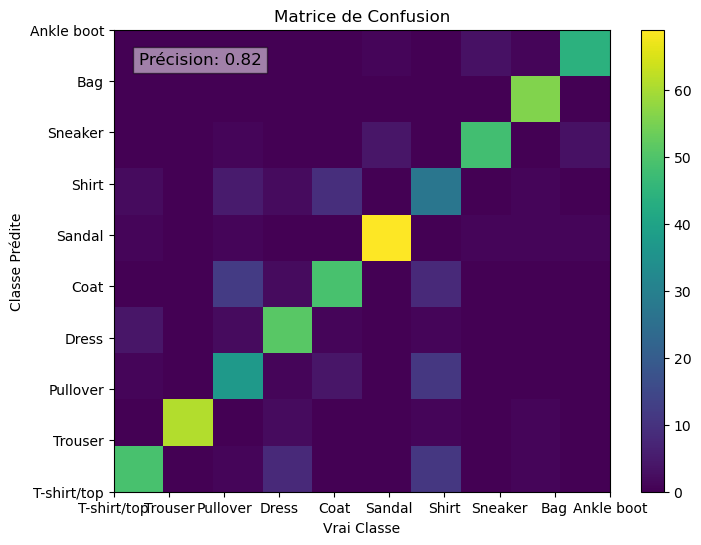

In [106]:
ev.matrice_confusion(idx_to_type, y_pred, Ytma)

In [15]:
dfr = pd.DataFrame.from_records(Xr)
dfr

,0,1,2,3,4,5,6,7,8,9,...,68,69,70,71,72,73,74,75,76,77
0,-0.184765,-0.808178,-0.500295,0.763921,-0.058106,1.125236,-0.306711,0.418369,0.636394,0.629854,...,-0.337532,-0.929791,-0.610722,0.880762,-0.152846,0.673413,-0.565676,0.413560,-0.029253,-0.273933
1,-1.111452,0.870387,-0.167188,-1.778372,0.941276,0.120496,-0.445132,-1.081183,-1.179281,1.163212,...,1.710943,1.089901,-1.503541,-0.097367,0.418852,-2.405562,-0.557004,-0.458730,-0.705671,1.089719
2,0.527741,1.654726,0.429405,0.713299,2.354609,-1.223086,2.242128,-0.151931,-0.376095,-0.741207,...,3.634926,0.425528,-0.128800,-0.963515,-0.491392,-1.347794,0.953904,-0.008467,-1.076748,1.224126
3,1.580848,-0.533179,0.291252,-1.169477,0.441902,0.717779,-1.893558,-0.717263,0.316159,-0.036079,...,0.649004,0.074290,-0.971232,-0.716214,-0.034277,-0.726040,1.401815,-0.715834,-0.115105,-0.863027
4,1.067709,0.714937,-1.630218,-1.358131,-0.981845,-1.524488,-1.833236,0.693933,0.543813,-1.017870,...,1.471118,-0.583917,-1.452843,-1.234219,-0.351692,0.553740,0.285202,0.272198,-0.460442,-0.291909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1.771578,0.752568,-0.908850,-0.621099,-0.452202,-1.831438,-1.134487,-0.733884,0.505275,-0.695786,...,-0.350544,1.284620,0.887748,0.904731,0.839604,0.942852,-0.622744,0.013666,1.463237,0.565978
5996,-0.071002,-1.666734,0.733547,-0.695875,-1.349042,-1.145600,0.840883,0.028833,0.523058,0.189870,...,0.207650,1.018415,0.017756,-1.197719,0.170454,0.064397,-1.422816,-0.422304,0.988665,1.265422
5997,-0.577013,0.602675,1.965158,0.491317,0.075655,-0.193078,-0.120224,-1.634672,2.449773,-0.510553,...,-0.211839,1.291621,-2.100412,1.041443,3.575052,0.413634,0.128653,1.083246,-1.603904,1.069468
5998,0.199952,1.542317,0.253310,-2.467493,-0.780367,1.771225,-0.005127,1.110947,1.540876,-0.986384,...,0.488652,-1.044708,1.958279,-0.398763,-1.805295,0.284861,-1.714517,0.020840,-0.676967,-1.477703


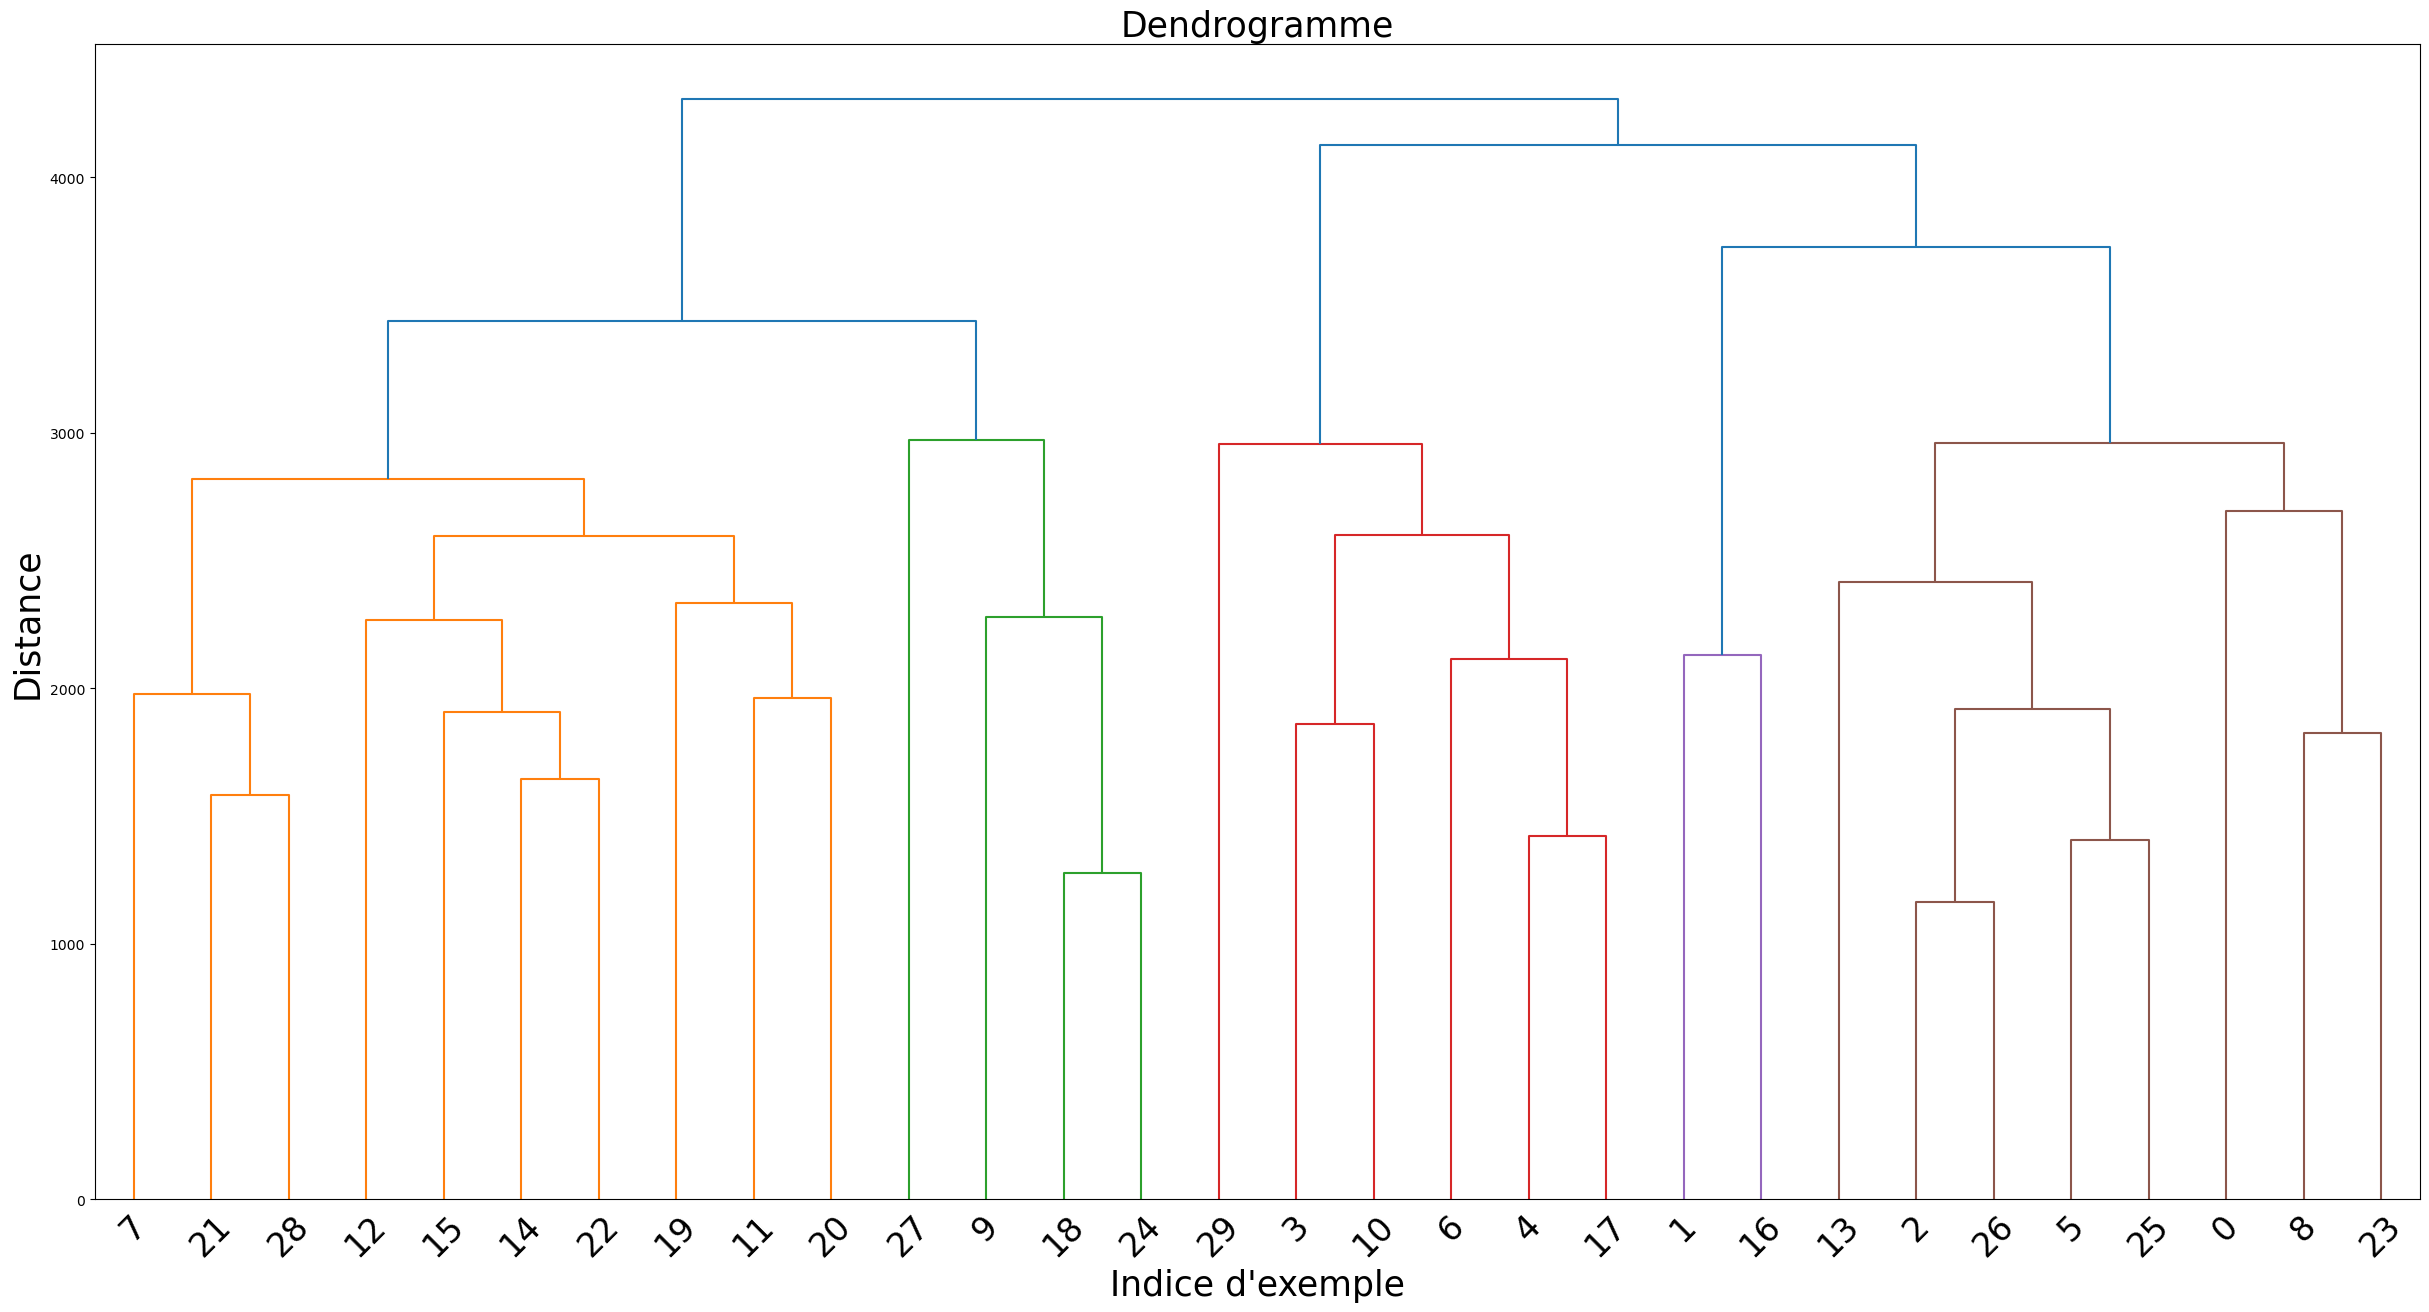

{'icoord': [[15.0, 15.0, 25.0, 25.0], [5.0, 5.0, 20.0, 20.0], [55.0, 55.0, 65.0, 65.0], [45.0, 45.0, 60.0, 60.0], [35.0, 35.0, 52.5, 52.5], [85.0, 85.0, 95.0, 95.0], [75.0, 75.0, 90.0, 90.0], [43.75, 43.75, 82.5, 82.5], [12.5, 12.5, 63.125, 63.125], [125.0, 125.0, 135.0, 135.0], [115.0, 115.0, 130.0, 130.0], [105.0, 105.0, 122.5, 122.5], [37.8125, 37.8125, 113.75, 113.75], [155.0, 155.0, 165.0, 165.0], [185.0, 185.0, 195.0, 195.0], [175.0, 175.0, 190.0, 190.0], [160.0, 160.0, 182.5, 182.5], [145.0, 145.0, 171.25, 171.25], [205.0, 205.0, 215.0, 215.0], [235.0, 235.0, 245.0, 245.0], [255.0, 255.0, 265.0, 265.0], [240.0, 240.0, 260.0, 260.0], [225.0, 225.0, 250.0, 250.0], [285.0, 285.0, 295.0, 295.0], [275.0, 275.0, 290.0, 290.0], [237.5, 237.5, 282.5, 282.5], [210.0, 210.0, 260.0, 260.0], [158.125, 158.125, 235.0, 235.0], [75.78125, 75.78125, 196.5625, 196.5625]], 'dcoord': [[0.0, np.float64(1582.6278779296163), np.float64(1582.6278779296163), 0.0], [0.0, np.float64(1976.8267501225291), 

In [13]:
#Dendogramme
import scipy.cluster.hierarchy

# Paramètre de la fenêtre d'affichage: 
plt.figure(figsize=(30, 15)) # taille : largeur x hauteur
plt.title('Dendrogramme', fontsize=25)    
plt.xlabel("Indice d'exemple", fontsize=25)
plt.ylabel('Distance', fontsize=25)

# Construction du dendrogramme pour notre clustering :
linkComplete = clust.LinkageComplete()
dendoData = scipy.cluster.hierarchy.dendrogram(
    clust.CHA_algorithme(data_train_X.iloc[:30],linkComplete,verbose=False), 
    leaf_font_size=24.,  # taille des caractères de l'axe des X
)

# Affichage du résultat obtenu:
plt.savefig("dendro.png")
plt.show()
print(d)

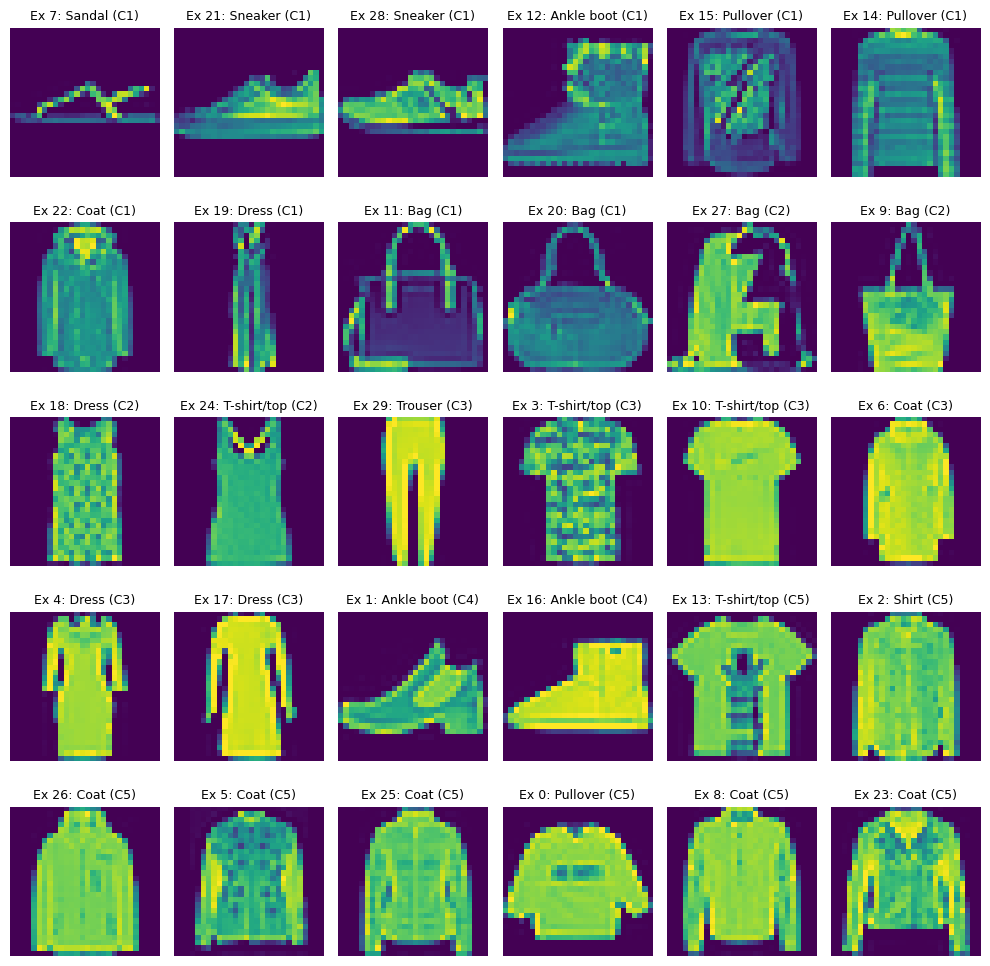

In [96]:
# fig, axes = plt.subplots(5, 6, figsize=(10, 12))
# axes = axes.flatten()

# for i in range(30):
#     ax = axes[i]
#     ax.imshow(X[i].reshape((28, 28)))   
#     ax.set_title(f"Ex {i}: {idx_to_type[Y[i]]}", fontsize=9)
#     ax.axis('off')

# plt.tight_layout()
# plt.savefig("dendro_l.png")
# plt.show()

# Pareil mais on prends le même ordre que les feuilles en bas du dendograme (donc rangé par classe)
fig, axes = plt.subplots(5, 6, figsize=(10, 10))
axes = axes.flatten()



# Chaque classe
index = 0
for elem in dendoData["leaves"]:
    trueIndex = int(elem)
    ax = axes[index]
    ax.imshow(X[trueIndex].reshape((28, 28)))   
    ax.set_title(f"Ex {trueIndex}: {idx_to_type[Y[trueIndex]]} ({dendoData["leaves_color_list"][index]})", fontsize=9)
    ax.axis('off')

    index = index + 1

plt.tight_layout()
plt.savefig("dendro_l_ranger.png")
plt.show()

Les résultats sont cohérents (Les C? sont les classes trouvé par l'algo), 
on remarque premièrement que nos algorithmes on tendance à classifier selon la luminosité puisque la 7 à 20 sont peut lumineuse et toutes dans la même classe ainsi que la classe allant de 13 à 23 étant plutôt lumineuse.
Puis en second, on peut voir que généralement, les classe on des images qui se ressemble.

=> L'algorithme fait donc un lien en fussionnant un peut par rapport au forme et un peut par rapport à la luminosité des images.


## KMoyennes

In [58]:
kmeans2 = clust.KMoyennes(K=10)
print("Instance de KMoyennes :", kmeans2)

les_centres, l_affectation = kmeans2.train(dfr, 0.05, 100,verbose=True)

Instance de KMoyennes : KMoyennes (K=10, Distance euclidienne)
iteration n°1 : Inertie = 442795.5312352868 Difference =  5237.017896252568
iteration n°2 : Inertie = 439958.922123449 Difference =  2836.60911183781
iteration n°3 : Inertie = 437924.96035677264 Difference =  2033.961766676337
iteration n°4 : Inertie = 436552.23704096663 Difference =  1372.7233158060117
iteration n°5 : Inertie = 435558.0090190469 Difference =  994.2280219197273
iteration n°6 : Inertie = 434761.81643381866 Difference =  796.1925852282438
iteration n°7 : Inertie = 434176.2425665471 Difference =  585.5738672715379
iteration n°8 : Inertie = 433728.3066340267 Difference =  447.93593252042774
iteration n°9 : Inertie = 433422.8298304604 Difference =  305.476803566271
iteration n°10 : Inertie = 433206.7313473985 Difference =  216.0984830619418
iteration n°11 : Inertie = 433016.82871588913 Difference =  189.9026315093506
iteration n°12 : Inertie = 432871.3678358171 Difference =  145.4608800720307
iteration n°13 : In

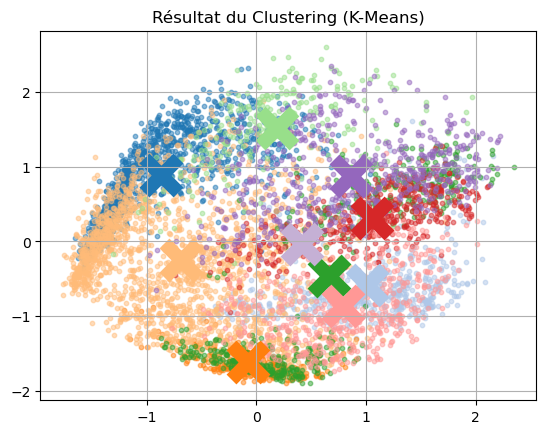

In [59]:
clust.affiche_resultat(dfr,les_centres,l_affectation)

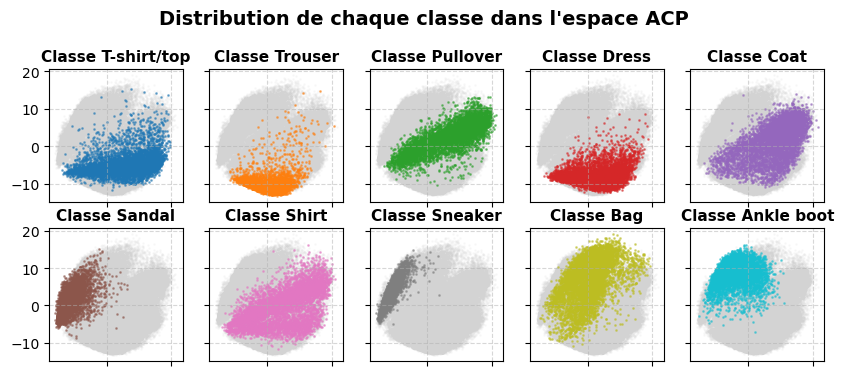

In [70]:
colors = plt.cm.tab10.colors

# Preparation de la figure
fig, axes = plt.subplots(5, 5, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.flatten()

# Pour le calcul des indice plus tard
distance = clust.DistanceEuclidienne()
intertieParC = np.zeros(Nc)
Dk = np.zeros(Nc)
clustMid = np.zeros((Nc, X_proj.shape[1]))

for c in range(Nc):
    # Affichage de la classe dans le bon graphe
    ax = axes[c]
    
    ax.scatter(X_proj[:, 0], X_proj[:, 1], c='lightgray', s=1, alpha=0.1)
    
    mask = (Y == c)
    ax.scatter(X_proj[mask, 0], X_proj[mask, 1], c=[colors[c % len(colors)]], 
               label=f"Classe {c}", marker="o", s=1, alpha=0.5)
    
    ax.set_title(f"Classe {idx_to_type[c]}", fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)

    # Calcul inertie
    for i in range(len(mask)):
        if mask[i] == 1:
            calcDist = distance.calcule(X_proj[i, 0:1], X_proj[mask, 0:1])**2
            intertieParC[c] = intertieParC[c] + np.sum(calcDist)
            if Dk[c] < np.max(calcDist):
                Dk[c] = np.max(calcDist)

    clustMid[c] = np.mean(X_proj[mask], axis=0)

for i in range(Nc, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Distribution de chaque classe dans l'espace ACP", fontsize=14, fontweight='bold', y=0.94)
plt.tight_layout
plt.savefig("acp_sep.png")
plt.show()

En comparant on voit que le clustering confond plusieurs groupes qui se chevauchaient dans les deux premières dimensions après ACP,
Sur le croissant inférieur on a 5-6 classes réelles mais k-means n'en distingue que 4 alors que sur le croissant supérieur on doit en distinguer près de 4 mais kmean en trouve 6

In [71]:
# Variable + calcul co_intertie et co_dist
distance = clust.DistanceEuclidienne()
co_inertie = np.sum(intertieParC)
co_dist = np.sum(Dk)
sepMin = 99999999999

# Calcul sepMin
for i in clustMid:
    allDist = distance.calcule(i, clustMid)**2
    for e in allDist:
        if e != 0:
            if sepMin > e:
                sepMin = e


# Calcul les 2 indices
XieBeni = co_inertie / sepMin
Dunn = co_dist / sepMin

print(co_inertie)
print(co_dist)
print(sepMin)

# Affiche les 2 indices
print(f"XieBeni {XieBeni}")
print(f"Dunn {Dunn}")

## PAS SURE DU CODE ET JE NE SAIS PAS COMMENT L'INTERPRÉTÉ
# Je sais que dun doit être bas et IxB bas mais sinon je n'ai pas d'ordre de grandeur

23591449696.73344
9548.134589820258
3.2991611198063167
XieBeni 7150741912.877059
Dunn 2894.1098185531473
